Shape: (37941, 12)
                    t    toy      p  Ws1    Wd1     T1  Ws2    Wd2     T2  \
0 1999-01-01 03:00:00  0.125  1.267  4.9  135.0  275.8  4.9  135.0  275.8   
1 1999-01-01 04:00:00  0.167  1.515  5.0  126.9  275.8  5.0  126.9  275.8   
2 1999-01-01 05:00:00  0.208  1.915  5.9  135.7  275.5  5.9  135.7  275.5   
3 1999-01-01 06:00:00  0.250  1.613  5.3  146.6  275.0  5.3  146.6  275.0   
4 1999-01-01 07:00:00  0.292  1.776  6.1  117.4  274.5  5.9  130.2  274.8   

   Ws3    Wd3     T3  
0  4.9  135.0  275.8  
1  5.0  126.9  275.8  
2  5.9  135.7  275.5  
3  5.3  146.6  275.0  
4  5.9  130.2  274.8  

--- dtypes ---
t      datetime64[ns]
toy           float64
p             float64
Ws1           float64
Wd1           float64
T1            float64
Ws2           float64
Wd2           float64
T2            float64
Ws3           float64
Wd3           float64
T3            float64
dtype: object

--- missing count ---
Ws3    1300
Wd3    1300
T3     1300
Ws2    1298
Wd2    1298
T2 

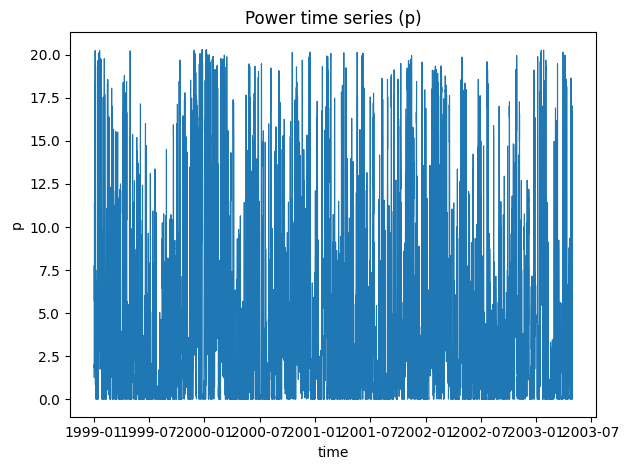

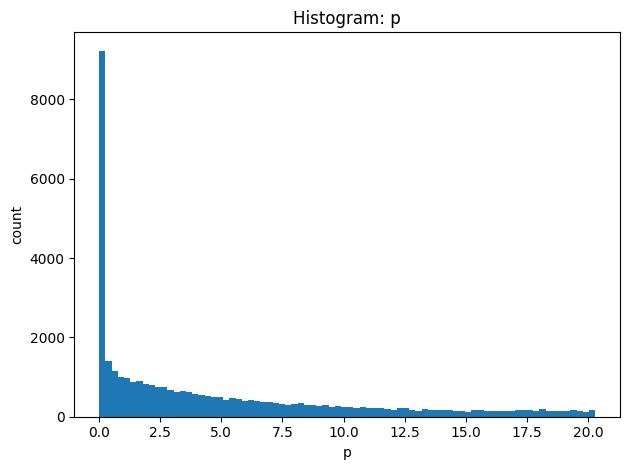

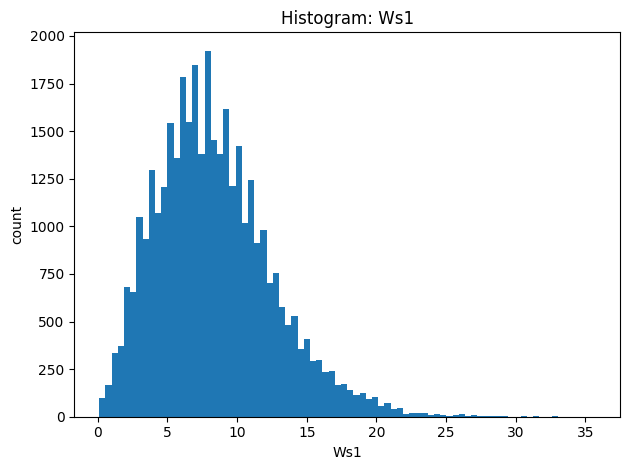

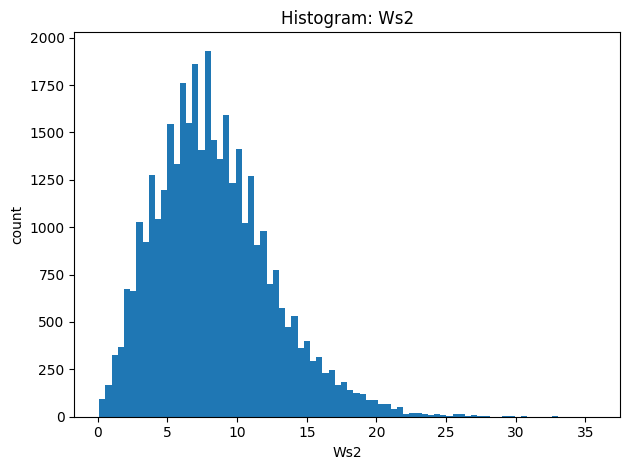

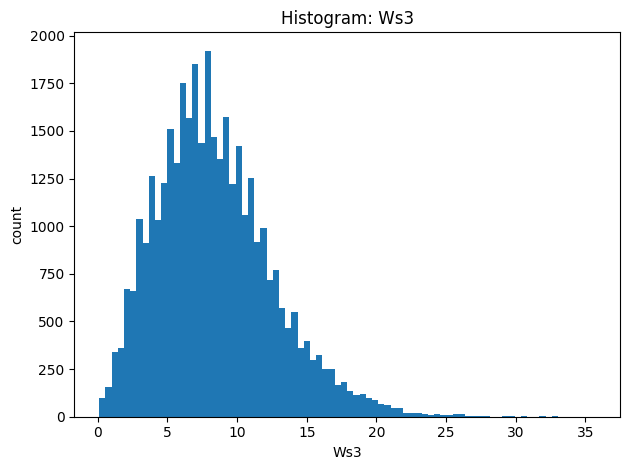

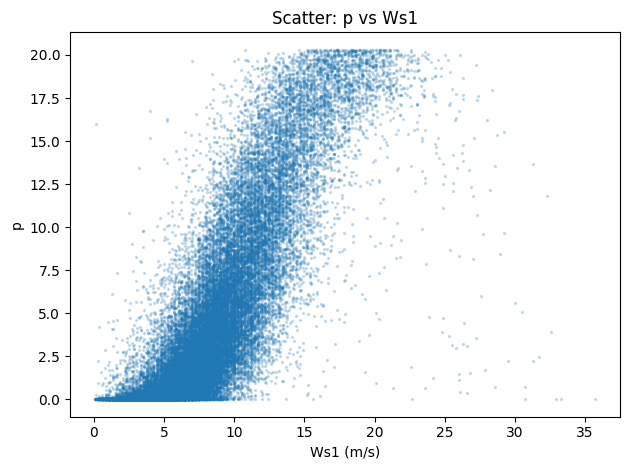

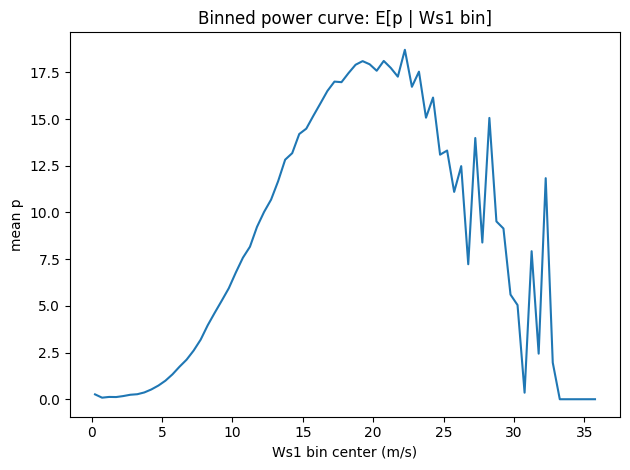

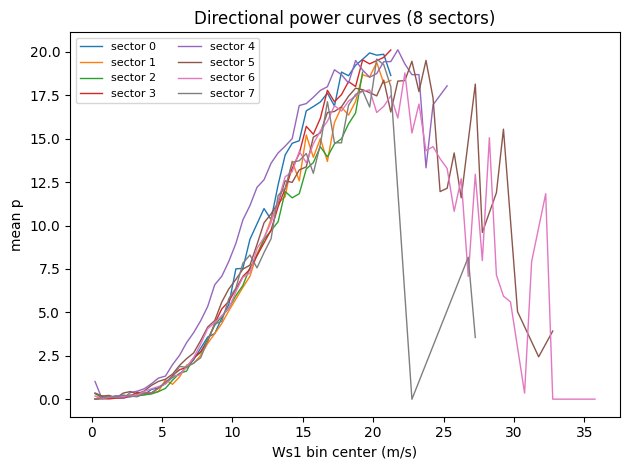


--- correlation matrix ---
         p    Ws1    Ws2    Ws3     T1     T2     T3
p    1.000  0.827  0.827  0.827 -0.122 -0.124 -0.126
Ws1  0.827  1.000  0.994  0.989 -0.153 -0.155 -0.156
Ws2  0.827  0.994  1.000  0.994 -0.152 -0.154 -0.156
Ws3  0.827  0.989  0.994  1.000 -0.152 -0.154 -0.156
T1  -0.122 -0.153 -0.152 -0.152  1.000  0.999  0.999
T2  -0.124 -0.155 -0.154 -0.154  0.999  1.000  0.999
T3  -0.126 -0.156 -0.156 -0.156  0.999  0.999  1.000


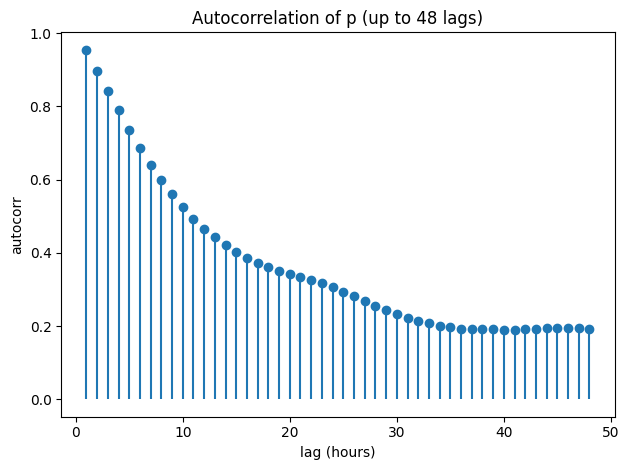

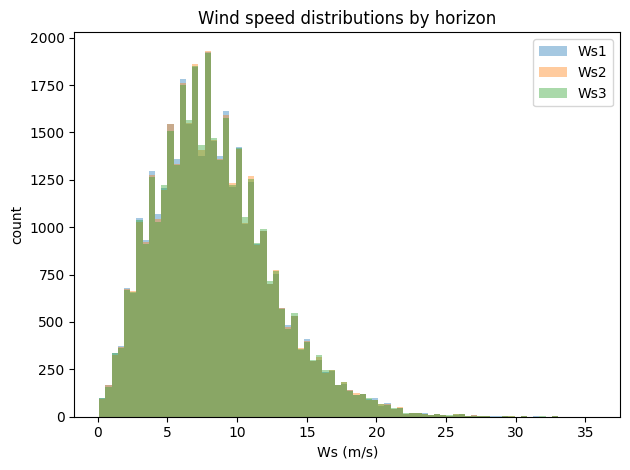


EDA done.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ========== 0) 读数据 ==========
# 任选一个文件
PATH = "data/cex4WindDataInterpolated.csv"
# PATH = "data/cex4WindDataNoInterpolation.csv"

df = pd.read_csv(PATH)

# 时间列：作业数据里 t 通常是字符串；这里尽量自动解析
df["t"] = pd.to_datetime(df["t"], errors="coerce")
df = df.sort_values("t").reset_index(drop=True)

print("Shape:", df.shape)
print(df.head())

# ========== 1) 基本信息 & 缺失情况 ==========
print("\n--- dtypes ---")
print(df.dtypes)

print("\n--- missing count ---")
missing = df.isna().sum().sort_values(ascending=False)
print(missing)

print("\n--- missing rate (%) ---")
print((missing / len(df) * 100).round(2))

# 你关心的核心列（按你作业）
core_cols = ["p",
             "Ws1","Wd1","T1",
             "Ws2","Wd2","T2",
             "Ws3","Wd3","T3"]
core_cols = [c for c in core_cols if c in df.columns]

print("\n--- summary stats (core) ---")
print(df[core_cols].describe().T)

# ========== 2) 快速可视化：时间序列 ==========
# 注意：数据可能很长，画全量会很密；这里抽样画（每 5 个点画一个）
step = 5
plt.figure()
plt.plot(df["t"][::step], df["p"][::step], linewidth=0.8)
plt.title("Power time series (p)")
plt.xlabel("time")
plt.ylabel("p")
plt.tight_layout()
plt.show()

# ========== 3) 变量分布：风速 / 功率 ==========
for col in ["p", "Ws1", "Ws2", "Ws3"]:
    if col not in df.columns:
        continue
    x = df[col].dropna()
    plt.figure()
    plt.hist(x, bins=80)
    plt.title(f"Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.tight_layout()
    plt.show()

# ========== 4) Power curve（p vs Ws1）散点 + 分箱均值 ==========
# 只用同时有 p 和 Ws1 的样本
pc = df[["p","Ws1","Wd1"]].dropna()
plt.figure()
plt.scatter(pc["Ws1"], pc["p"], s=2, alpha=0.2)
plt.title("Scatter: p vs Ws1")
plt.xlabel("Ws1 (m/s)")
plt.ylabel("p")
plt.tight_layout()
plt.show()

# 分箱平均 power curve（最经典的非参数曲线）
bins = np.arange(0, 36.5, 0.5)  # 0.5 m/s bins，可改成 1.0
pc["Ws_bin"] = pd.cut(pc["Ws1"], bins=bins, include_lowest=True)

curve = pc.groupby("Ws_bin", observed=True)["p"].agg(["mean","count"]).reset_index()
# 提取每个 bin 的中心点作为 x
bin_centers = np.array([interval.mid for interval in curve["Ws_bin"]])
plt.figure()
plt.plot(bin_centers, curve["mean"], linewidth=1.5)
plt.title("Binned power curve: E[p | Ws1 bin]")
plt.xlabel("Ws1 bin center (m/s)")
plt.ylabel("mean p")
plt.tight_layout()
plt.show()

# ========== 5) 加风向：按风向 sector 的 power curve ==========
# 把风向分成 8 个扇区（你也可以用 4/12/16）
def wd_to_sector(wd_deg, n_sectors=8):
    # 将 [0,360) 分成 n_sectors 份
    # sector id: 0..n_sectors-1
    return (np.floor((wd_deg % 360) / (360 / n_sectors))).astype(int)

pc = pc.copy()
pc["sector"] = wd_to_sector(pc["Wd1"], n_sectors=8)

plt.figure()
for s in sorted(pc["sector"].unique()):
    sub = pc[pc["sector"] == s]
    sub = sub.dropna(subset=["Ws1","p"])
    sub["Ws_bin"] = pd.cut(sub["Ws1"], bins=bins, include_lowest=True)
    cur = sub.groupby("Ws_bin", observed=True)["p"].mean()
    x = np.array([interval.mid for interval in cur.index])
    plt.plot(x, cur.values, linewidth=1.0, label=f"sector {s}")
plt.title("Directional power curves (8 sectors)")
plt.xlabel("Ws1 bin center (m/s)")
plt.ylabel("mean p")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

# ========== 6) 相关性（线性相关仅作参考） ==========
corr_cols = [c for c in ["p","Ws1","Ws2","Ws3","T1","T2","T3"] if c in df.columns]
corr = df[corr_cols].corr()
print("\n--- correlation matrix ---")
print(corr.round(3))

# ========== 7) 滞后相关（p 的 persistence 证据） ==========
# 计算自相关：corr(p_t, p_{t-k})
p_series = df["p"].dropna().reset_index(drop=True)
max_lag = 48  # 看 2 天内
acf = []
lags = range(1, max_lag + 1)
for k in lags:
    acf.append(p_series.autocorr(lag=k))

plt.figure()
plt.stem(list(lags), acf, basefmt=" ")
plt.title("Autocorrelation of p (up to 48 lags)")
plt.xlabel("lag (hours)")
plt.ylabel("autocorr")
plt.tight_layout()
plt.show()

# ========== 8) 对比 Ws1/Ws2/Ws3 分布一致性 ==========
ws_cols = [c for c in ["Ws1","Ws2","Ws3"] if c in df.columns]
plt.figure()
for c in ws_cols:
    x = df[c].dropna()
    plt.hist(x, bins=80, alpha=0.4, label=c)
plt.title("Wind speed distributions by horizon")
plt.xlabel("Ws (m/s)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

print("\nEDA done.")



## Diurnal and Seasonal Patterns

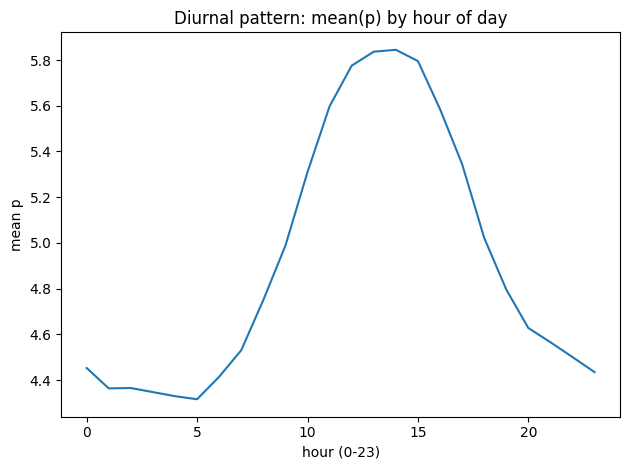

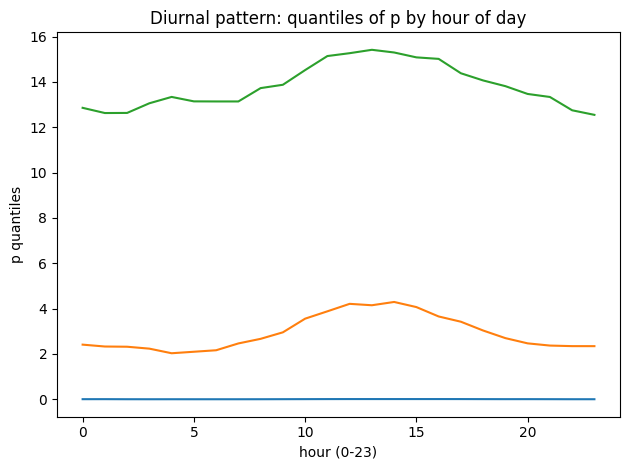

    hour      mean     q10     q50      q90  count
0      0  4.452856  0.0030  2.4100  12.8594   1567
1      1  4.363635  0.0040  2.3270  12.6296   1567
2      2  4.365227  0.0010  2.3175  12.6345   1566
3      3  4.347363  0.0000  2.2330  13.0606   1567
4      4  4.329637  0.0006  2.0300  13.3404   1567
5      5  4.316145  0.0000  2.0960  13.1445   1566
6      6  4.414635  0.0000  2.1620  13.1408   1565
7      7  4.530633  0.0000  2.4630  13.1408   1565
8      8  4.750392  0.0010  2.6660  13.7298   1565
9      9  4.988252  0.0030  2.9530  13.8770   1565
10    10  5.309889  0.0050  3.5560  14.5252   1565
11    11  5.597741  0.0070  3.8800  15.1444   1565
12    12  5.775368  0.0080  4.2100  15.2706   1565
13    13  5.836485  0.0080  4.1480  15.4198   1565
14    14  5.844712  0.0080  4.2930  15.3014   1565
15    15  5.795439  0.0080  4.0670  15.0860   1566
16    16  5.585323  0.0080  3.6530  15.0195   1566
17    17  5.344995  0.0075  3.4210  14.3845   1566
18    18  5.022230  0.0055  3.0

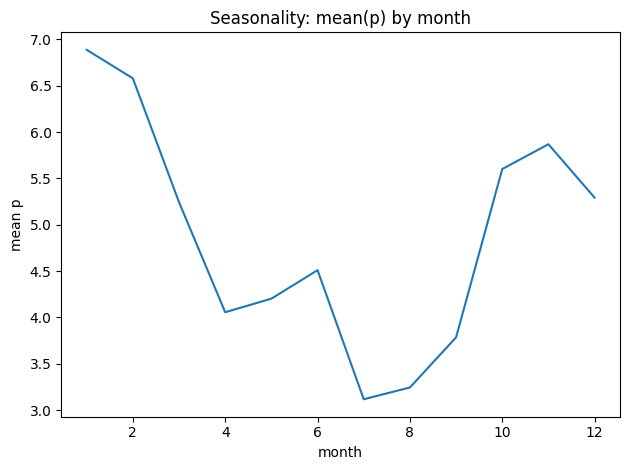

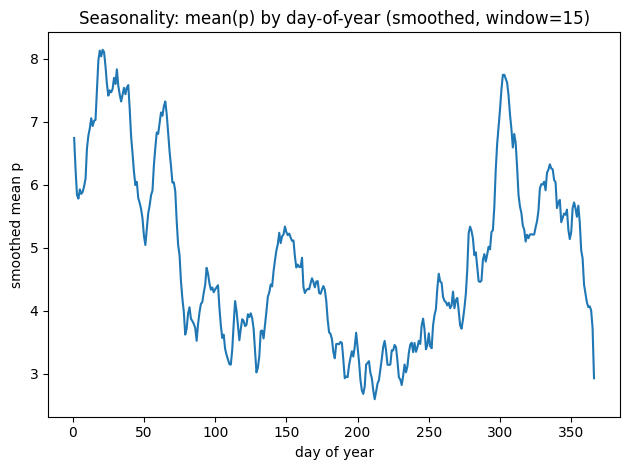

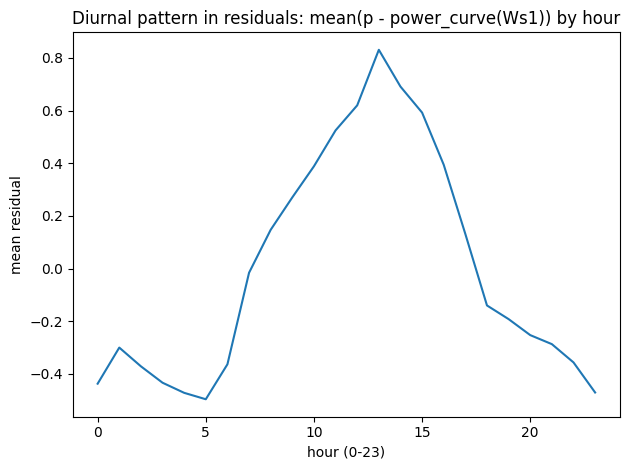

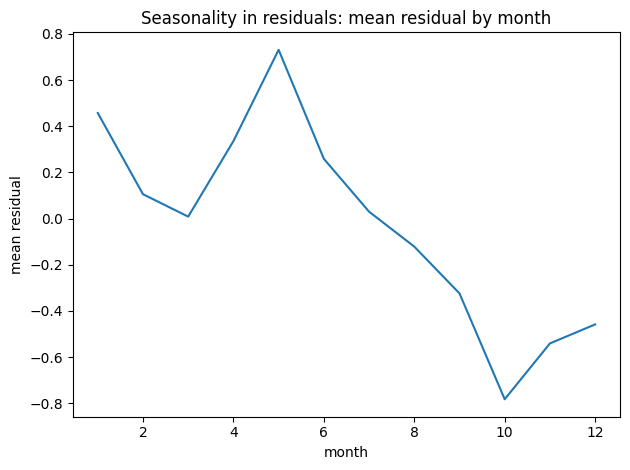

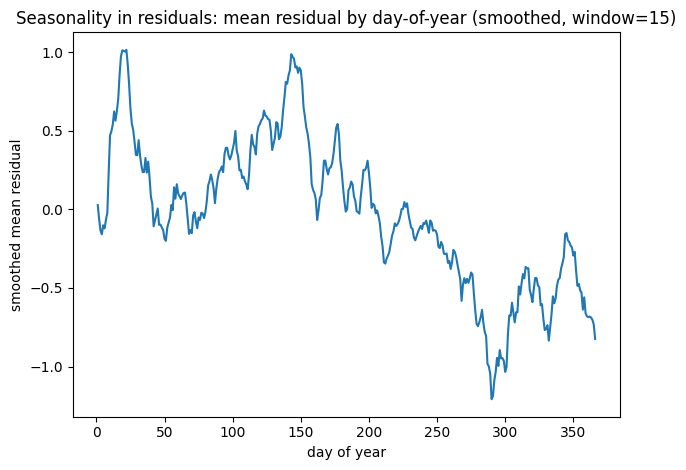

Done: diurnal & seasonal checks (both raw p and residuals).


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "data/cex4WindDataInterpolated.csv"
# PATH = "/mnt/data/cex4WindDataNoInterpolation.csv"

df = pd.read_csv(PATH)

# 解析时间
df["t"] = pd.to_datetime(df["t"], errors="coerce")
df = df.sort_values("t").reset_index(drop=True)

# 构造时间特征（若 t 不可用则退化用 toy）
df["hour"] = df["t"].dt.hour
df["month"] = df["t"].dt.month
df["doy"] = df["t"].dt.dayofyear

# ========= 1) 日内 pattern：p vs hour =========
tmp = df[["p", "hour"]].dropna()

g = tmp.groupby("hour")["p"]
hour_stats = pd.DataFrame({
    "mean": g.mean(),
    "q10": g.quantile(0.10),
    "q50": g.quantile(0.50),
    "q90": g.quantile(0.90),
    "count": g.count()
}).reset_index()

plt.figure()
plt.plot(hour_stats["hour"], hour_stats["mean"])
plt.title("Diurnal pattern: mean(p) by hour of day")
plt.xlabel("hour (0-23)")
plt.ylabel("mean p")
plt.tight_layout()
plt.show()

plt.figure()
plt.plot(hour_stats["hour"], hour_stats["q10"])
plt.plot(hour_stats["hour"], hour_stats["q50"])
plt.plot(hour_stats["hour"], hour_stats["q90"])
plt.title("Diurnal pattern: quantiles of p by hour of day")
plt.xlabel("hour (0-23)")
plt.ylabel("p quantiles")
plt.tight_layout()
plt.show()

print(hour_stats)

# ========= 2) 季节性：按月份的 p =========
tmp = df[["p", "month"]].dropna()
m = tmp.groupby("month")["p"].mean().reset_index()

plt.figure()
plt.plot(m["month"], m["p"])
plt.title("Seasonality: mean(p) by month")
plt.xlabel("month")
plt.ylabel("mean p")
plt.tight_layout()
plt.show()

# ========= 3) 季节性：按 day-of-year 的平滑曲线 =========
# 先按 doy 求均值，再用滑动平均平滑（避免噪声）
tmp = df[["p", "doy"]].dropna()
doy_mean = tmp.groupby("doy")["p"].mean().reindex(range(1, 367)).astype(float)

# 平滑窗口：例如 15 天
win = 15
doy_smooth = doy_mean.rolling(win, center=True, min_periods=1).mean()

plt.figure()
plt.plot(doy_smooth.index, doy_smooth.values)
plt.title(f"Seasonality: mean(p) by day-of-year (smoothed, window={win})")
plt.xlabel("day of year")
plt.ylabel("smoothed mean p")
plt.tight_layout()
plt.show()

# ========= 4) 更“公平”的检验：去掉风速影响后的日内/季节 pattern =========
# 思路：先用一个非常粗的 power curve（按 Ws1 分箱）得到 baseline，再看残差是否还有日内/季节结构
cols = ["p", "Ws1", "hour", "month", "doy"]
tmp = df[cols].dropna().copy()

bins = np.arange(0, 36.5, 0.5)
tmp["Ws_bin"] = pd.cut(tmp["Ws1"], bins=bins, include_lowest=True)
pc_mean = tmp.groupby("Ws_bin", observed=True)["p"].mean()
tmp["p_pc"] = tmp["Ws_bin"].map(pc_mean)
tmp["resid"] = tmp["p"] - tmp["p_pc"]

# 残差的日内模式
r_hour = tmp.groupby("hour")["resid"].mean().reset_index()
plt.figure()
plt.plot(r_hour["hour"], r_hour["resid"])
plt.title("Diurnal pattern in residuals: mean(p - power_curve(Ws1)) by hour")
plt.xlabel("hour (0-23)")
plt.ylabel("mean residual")
plt.tight_layout()
plt.show()

# 残差的季节模式（按月）
r_month = tmp.groupby("month")["resid"].mean().reset_index()
plt.figure()
plt.plot(r_month["month"], r_month["resid"])
plt.title("Seasonality in residuals: mean residual by month")
plt.xlabel("month")
plt.ylabel("mean residual")
plt.tight_layout()
plt.show()

# 残差的 day-of-year 平滑曲线
r_doy = tmp.groupby("doy")["resid"].mean().reindex(range(1, 367)).astype(float)
r_doy_smooth = r_doy.rolling(win, center=True, min_periods=1).mean()

plt.figure()
plt.plot(r_doy_smooth.index, r_doy_smooth.values)
plt.title(f"Seasonality in residuals: mean residual by day-of-year (smoothed, window={win})")
plt.xlabel("day of year")
plt.ylabel("smoothed mean residual")
plt.tight_layout()
plt.show()

print("Done: diurnal & seasonal checks (both raw p and residuals).")


### GARCH Test ()

                            AutoReg Model Results                             
Dep. Variable:                      p   No. Observations:                37583
Model:                     AutoReg(1)   Log Likelihood              -71891.072
Method:               Conditional MLE   S.D. of innovations              1.639
Date:                Tue, 16 Dec 2025   AIC                         143788.144
Time:                        08:59:03   BIC                         143813.747
Sample:                             1   HQIC                        143796.272
                                37583                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2239      0.011     19.736      0.000       0.202       0.246
p.L1           0.9544      0.002    619.881      0.000       0.951       0.957
                                    Roots           

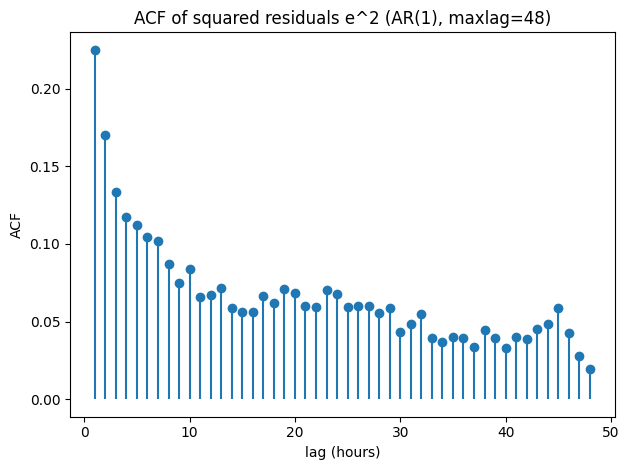

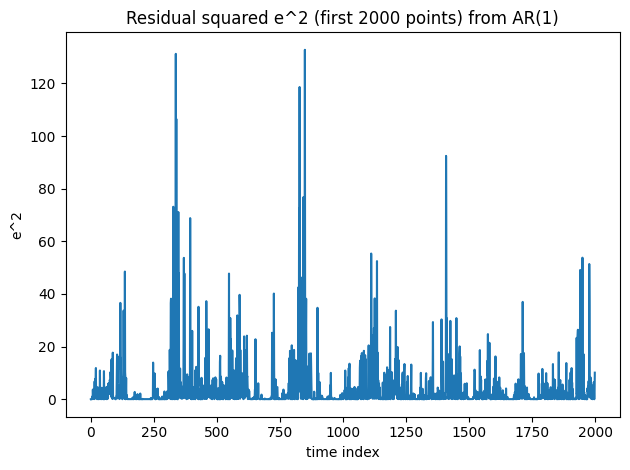

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.stats.diagnostic import het_arch
from statsmodels.tsa.stattools import acf

PATH = "data/cex4WindDataInterpolated.csv"
df = pd.read_csv(PATH)
df["t"] = pd.to_datetime(df["t"], errors="coerce")
df = df.sort_values("t").reset_index(drop=True)

# 只取功率序列，去掉缺失
p = df["p"].dropna().astype(float).reset_index(drop=True)

# ===== 1) 拟合 AR(1) =====
# old_names=False 避免 statsmodels 新旧接口警告
ar1 = AutoReg(p, lags=1, old_names=False).fit()
print(ar1.summary())

# 残差 e_t（与拟合样本对齐）
e = ar1.resid
e = np.asarray(e)

print("\nAR(1) residual std:", np.std(e))

# ===== 2) ARCH LM test =====
lags = 24  # 常用：12~48 之间（半天~两天）
lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(e, nlags=lags)
print(f"\nARCH LM test (lags={lags})")
print("LM stat:", lm_stat)
print("LM p-value:", lm_pvalue)
print("F  stat:", f_stat)
print("F  p-value:", f_pvalue)
print(f"p-value (LM): {lm_pvalue:.50e}")
print(f"p-value (F) : {f_pvalue:.50e}")

# ===== 3) ACF of squared residuals =====
e2 = e**2
maxlag = 48
acf_e2 = acf(e2, nlags=maxlag, fft=True)

plt.figure()
plt.stem(range(1, maxlag+1), acf_e2[1:], basefmt=" ")
plt.title(f"ACF of squared residuals e^2 (AR(1), maxlag={maxlag})")
plt.xlabel("lag (hours)")
plt.ylabel("ACF")
plt.tight_layout()
plt.show()

# ===== 4) 看波动聚集：e^2 前 2000 点 =====
plt.figure()
plt.plot(e2[:2000])
plt.title("Residual squared e^2 (first 2000 points) from AR(1)")
plt.xlabel("time index")
plt.ylabel("e^2")
plt.tight_layout()
plt.show()
